# Phase 11 — Real LLM Evaluation, Error Analysis & Low-FP Deployment
**Capstone 2 | Phases 6–11**

This notebook covers the final four parts of the pipeline:

| Part | Description |
|---|---|
| **Pert 11a** | Generate 80 real GPT-4o-mini samples (10 per content type) |
| **Part 11b** | Evaluate Original RF, Hybrid RF, and LightGBM on real eval set |
| **Part 11c** | Visualize generalization results — confusion matrices, F1 bar chart, per-content-type accuracy |
| **Save bundle** | Save `models/avh_best_bundle.pkl` (deploy model + all pipeline objects) |
| **Part 12a** | Error analysis for the deploy model on real eval set — confidence, content-type breakdown, top errors |
| **Part 12b** | LIME word-level explanations for deploy model — 4 passes on real eval samples |
| **Part 13** | Low-FP upgrade — calibrated LightGBM v2 with leak-safe split, human-style augmentation, and threshold tuning → `models/avh_best_bundle_v2.pkl` |

**Real LLM results:**
| Model | In-Dist F1 | Real LLM F1 | Gap | AI-Class F1 |
|---|---|---|---|---|
| Original RF (TF-IDF) | 0.8952 | 0.3182 | −0.577 | **0.000** |
| Hybrid RF (BERT + stylometric) | 0.8788 | 0.9866 | −0.1078 | 0.9877 |
| LightGBM (BERT + stylometric) | 0.8731 | 0.9933 | +0.1202 | 0.9938 |

> **11a** requires `OPENAI_API_KEY` in your environment. All other cells run without an API key using the pre-generated `df_real_eval` dataframe.  
> **Part 13** optionally reads `real_human_extra.csv` and `real_human_holdout.csv` from the working directory for additional threshold tuning.

**Loads:** `outputs/hybrid_model_bundle.pkl` + `outputs/best_rf_bundle.pkl`  
**Saves:** `models/avh_best_bundle.pkl` and `models/avh_best_bundle_v2.pkl`


In [ ]:
import numpy as np, random, os
RANDOM_SEED = 42
random.seed(RANDOM_SEED); np.random.seed(RANDOM_SEED)
os.environ['PYTHONHASHSEED'] = str(RANDOM_SEED)
try:
    import torch
    torch.manual_seed(RANDOM_SEED); torch.cuda.manual_seed_all(RANDOM_SEED)
    torch.backends.cudnn.deterministic = True; torch.backends.cudnn.benchmark = False
    print(f"Seeds fixed (numpy + random + torch): {RANDOM_SEED}")
except ImportError:
    print(f"Seeds fixed (numpy + random): {RANDOM_SEED}")
print("Always run this cell first on every restart.")


In [ ]:
# ── HANDOFF: load hybrid bundle + RF bundle ──
import joblib, numpy as np

hybrid_b = joblib.load('outputs/hybrid_model_bundle.pkl')
rf_hybrid               = hybrid_b['rf_hybrid']
lgbm_model              = hybrid_b['lgbm_model']
deploy_model            = hybrid_b['deploy_model']
deploy_name             = hybrid_b['deploy_name']
top_stylometric_indices = hybrid_b['top_stylometric_indices']
tfidf_temp              = hybrid_b['tfidf_temp']
char_temp               = hybrid_b['char_temp']
selector_temp           = hybrid_b['selector_temp']
augmented_df_sr         = hybrid_b['augmented_df_sr']
f1_hybrid_val           = hybrid_b['f1_hybrid_val']
f1_lgbm_val             = hybrid_b['f1_lgbm_val']
f1_hybrid_ai_val        = hybrid_b['f1_hybrid_ai_val']
f1_lgbm_ai_val          = hybrid_b['f1_lgbm_ai_val']

rf_b          = joblib.load('outputs/best_rf_bundle.pkl')
ultimate_best = rf_b['best_rf']
y_test_sr     = rf_b['y_test_sr']

deploy_predict = lambda X: deploy_model.predict(X)

print(f"Loaded deploy model: {deploy_name}")
print(f"Val F1 — RF: {f1_hybrid_val:.4f} | LGBM: {f1_lgbm_val:.4f}")


## 11a. Generate Real GPT-4o-mini Samples

Generates 10 samples per content type (80 total) using GPT-4o-mini across all 8 content categories. Temperature is varied slightly across samples for diversity.

Requires `OPENAI_API_KEY` in your environment (`os.getenv("OPENAI_API_KEY")`). If not provided, the cell will attempt to load `ai_vs_human_eval_dataset.csv` from the working directory. Human samples are drawn from the original dataset, pairing them with the GPT samples to form the 150-sample evaluation set.


In [ ]:
# CELL B — generate real GPT-4o-mini eval samples
import os
import time
import pandas as pd
from getpass import getpass
from openai import OpenAI

# API key (do not hardcode)
api_key = os.getenv("OPENAI_API_KEY", "").strip()
if not api_key:
    api_key = getpass("Enter your OpenAI API key (leave blank to skip generation): ").strip()

client = OpenAI(api_key=api_key) if api_key else None
if client:
    print("Client initialized successfully")
else:
    print("No API key provided. Will use existing ai_vs_human_eval_dataset.csv if available.")

content_types = [
    "blog_post", "news_article", "product_review", "academic_paper",
    "social_media", "email", "creative_writing", "article"
]

prompts = {
    "blog_post":        "Write a 200-word personal blog post about productivity tips for remote workers. Conversational, first-person tone.",
    "news_article":     "Write a 200-word news article about a city council vote to expand public transit funding. Objective, journalistic style.",
    "product_review":   "Write a 200-word product review for wireless noise-cancelling headphones. Include pros, cons, and a recommendation.",
    "academic_paper":   "Write a 200-word academic paragraph arguing social media has negative effects on adolescent mental health. Formal register.",
    "social_media":     "Write 200 words of social media posts about learning to cook new recipes. Casual, engaging, with hashtags.",
    "email":            "Write a 200-word professional email requesting team feedback on a project proposal before Friday's deadline.",
    "creative_writing": "Write a 200-word opening for a short story about a lighthouse keeper who finds a mysterious object on the shore.",
    "article":          "Write a 200-word general interest article about the growing popularity of urban gardening in cities."
}

N_PER_TYPE = 10
real_records = []

if client:
    print("Generating GPT-4o-mini samples...")
    for ct in content_types:
        print(f"  {ct}...")
        for i in range(N_PER_TYPE):
            try:
                resp = client.chat.completions.create(
                    model="gpt-4o-mini",
                    messages=[{"role": "user", "content": prompts[ct]}],
                    max_tokens=400,
                    temperature=0.7 + (i % 5) * 0.04
                )
                text = (resp.choices[0].message.content or "").strip()
                if text:
                    real_records.append({
                        "text_content": text,
                        "label": 1,
                        "content_type": ct,
                        "source": "gpt-4o-mini"
                    })
                time.sleep(0.25)
            except Exception as e:
                print(f"    GPT error {ct} #{i+1}: {e}")

print(f"GPT complete: {len(real_records)} AI samples")

df_orig = pd.read_csv("ai_human_content_detection_dataset.csv")
human_records = []

for ct in content_types:
    pool = df_orig[(df_orig["label"] == 0) & (df_orig["content_type"] == ct)].head(N_PER_TYPE)
    for _, row in pool.iterrows():
        human_records.append({
            "text_content": row["text_content"],
            "label": 0,
            "content_type": ct,
            "source": "human"
        })

if real_records:
    df_real_eval = pd.DataFrame(real_records + human_records)
    df_real_eval.to_csv("ai_vs_human_eval_dataset.csv", index=False)
elif os.path.exists("ai_vs_human_eval_dataset.csv"):
    df_real_eval = pd.read_csv("ai_vs_human_eval_dataset.csv")
    print("Loaded existing ai_vs_human_eval_dataset.csv")
else:
    df_real_eval = pd.DataFrame(human_records)
    print("Warning: using human-only eval fallback because no GPT samples were generated.")

print(f"Evaluation dataset size: {len(df_real_eval)}")
if len(df_real_eval):
    print(df_real_eval.groupby(["source", "content_type"]).size().unstack(fill_value=0).to_string())
print("\ndf_real_eval ready.")



Enter your OpenAI API key (leave blank to skip generation):  ········


Client initialized successfully
Generating GPT-4o-mini samples...
  blog_post...
  news_article...
  product_review...
  academic_paper...
  social_media...
  email...
  creative_writing...
  article...
GPT complete: 80 AI samples
Evaluation dataset size: 150
content_type  academic_paper  article  blog_post  creative_writing  email  news_article  product_review  social_media
source                                                                                                               
gpt-4o-mini               10       10         10                10     10            10              10            10
human                     10       10         10                10      0            10              10            10

df_real_eval ready.


## Part 11b — Evaluate All Three Models on Real GPT Output

Also prints per-source accuracy breakdown and the full classification report for the selected `deploy_model`.

The `build_classical_features()` helper re-runs the full feature pipeline on the eval set using the fitted objects from training — no leakage.


In [ ]:
# PART 11b: EVALUATE ON REAL GPT-4o-mini OUTPUT
from sklearn.metrics import f1_score, classification_report
import numpy as np
import pandas as pd
import time

def _safe_ai_f1(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    if len(np.unique(y_true)) < 2:
        return 0.0
    vals = f1_score(y_true, y_pred, average=None, zero_division=0)
    return float(vals[1]) if len(vals) > 1 else 0.0

def build_classical_features(df_eval):
    df_e = df_eval.copy()

    if "content_type" not in df_e.columns:
        df_e["content_type"] = "article"

    intrinsic_cols = [
        "word_count","character_count","sentence_count","lexical_diversity",
        "avg_sentence_length","avg_word_length","punctuation_ratio",
        "flesch_reading_ease","gunning_fog_index","grammar_errors",
        "passive_voice_ratio","predictability_score","burstiness","sentiment_score"
    ]
    for col in intrinsic_cols:
        if col not in df_e.columns:
            df_e[col] = 0.0

    X_num = df_e[intrinsic_cols].fillna(0)
    adv_df = pd.DataFrame(list(df_e["text_content"].astype(str).apply(extract_advanced_features)))

    if "content_type" in augmented_df_sr.columns:
        ct_cols = pd.get_dummies(augmented_df_sr["content_type"], prefix="content", drop_first=True).columns.tolist()
    else:
        ct_cols = []
    ct_dum = pd.get_dummies(df_e["content_type"], prefix="content", drop_first=False)
    for col in ct_cols:
        if col not in ct_dum.columns:
            ct_dum[col] = 0
    ct_dum = ct_dum[ct_cols] if ct_cols else pd.DataFrame(index=df_e.index)

    X_tf = tfidf_temp.transform(df_e["text_content"].astype(str)).toarray()
    X_ch = char_temp.transform(df_e["text_content"].astype(str)).toarray()

    X_all = np.hstack([X_num.values, adv_df.values, ct_dum.values, X_tf, X_ch])
    X_sel = selector_temp.transform(np.abs(X_all))
    return X_sel

if "df_real_eval" not in globals() or len(df_real_eval) == 0:
    raise ValueError("df_real_eval is missing/empty. Run your GPT sample generation cell first.")

y_eval = df_real_eval["label"].values
X_classical_eval = build_classical_features(df_real_eval)
eval_texts_list = df_real_eval["text_content"].astype(str).tolist()

# 1) Original TF-IDF RF
y_pred_orig = ultimate_best["Model"].predict(X_classical_eval)
f1_orig_real = f1_score(y_eval, y_pred_orig, average="macro", zero_division=0)
f1_orig_ai_real = _safe_ai_f1(y_eval, y_pred_orig)

# 2) Hybrid features for eval
print("Extracting frozen BERT embeddings for eval set...")
t0 = time.time()
X_bert_eval = get_bert_embeddings(eval_texts_list)
print(f"Done in {(time.time()-t0):.0f}s. Shape: {X_bert_eval.shape}")

X_stylo_eval = X_classical_eval[:, top_stylometric_indices]
X_hybrid_eval = np.hstack([X_bert_eval, X_stylo_eval])

# Optional guard
if hasattr(rf_hybrid, "n_features_in_") and X_hybrid_eval.shape[1] != rf_hybrid.n_features_in_:
    raise ValueError(f"Hybrid eval shape mismatch: {X_hybrid_eval.shape[1]} vs rf_hybrid expects {rf_hybrid.n_features_in_}")

# 3) Hybrid RF
y_pred_rf_eval = rf_hybrid.predict(X_hybrid_eval)
f1_rf_real = f1_score(y_eval, y_pred_rf_eval, average="macro", zero_division=0)
f1_rf_ai_real = _safe_ai_f1(y_eval, y_pred_rf_eval)

# 4) LightGBM
y_pred_lgbm_eval = lgbm_model.predict(X_hybrid_eval)
f1_lgbm_real = f1_score(y_eval, y_pred_lgbm_eval, average="macro", zero_division=0)
f1_lgbm_ai_real = _safe_ai_f1(y_eval, y_pred_lgbm_eval)

# Deploy model eval
y_pred_ft = deploy_predict(X_hybrid_eval)
f1_ft_real = f1_score(y_eval, y_pred_ft, average="macro", zero_division=0)
f1_ft_ai_real = _safe_ai_f1(y_eval, y_pred_ft)

df_real_eval["pred_orig"] = y_pred_orig
df_real_eval["pred_hybrid"] = y_pred_rf_eval
df_real_eval["pred_lgbm"] = y_pred_lgbm_eval
df_real_eval["pred_ft"] = y_pred_ft
df_real_eval["correct_orig"] = (y_eval == y_pred_orig)
df_real_eval["correct_hybrid"] = (y_eval == y_pred_rf_eval)
df_real_eval["correct_ft"] = (y_eval == y_pred_ft)

print("\n" + "=" * 72)
print("PART 11: GENERALISATION TO REAL GPT-4o-mini OUTPUT")
print("=" * 72)
print(f"{'Model':<40} {'In-Dist':>8} {'Real F1':>8} {'Gap':>8} {'AI F1':>8}")
print("-" * 72)
print(f"{'Original RF (TF-IDF)':<40} {ultimate_best['F1-Score']:>8.4f} {f1_orig_real:>8.4f} {f1_orig_real-ultimate_best['F1-Score']:>+8.4f} {f1_orig_ai_real:>8.4f}")
print(f"{'Hybrid RF (BERT+Stylo, domain-adaptive)':<40} {f1_hybrid_val:>8.4f} {f1_rf_real:>8.4f} {f1_rf_real-f1_hybrid_val:>+8.4f} {f1_rf_ai_real:>8.4f}")
print(f"{'LightGBM (BERT+Stylo, domain-adaptive)':<40} {f1_lgbm_val:>8.4f} {f1_lgbm_real:>8.4f} {f1_lgbm_real-f1_lgbm_val:>+8.4f} {f1_lgbm_ai_real:>8.4f}")
print("=" * 72)

print(f"\nDeployment model ({deploy_name}) report on real GPT output:")
print(classification_report(y_eval, y_pred_ft, target_names=["Human", "AI"]))

print("\nPer-source performance:")
for src in df_real_eval["source"].unique():
    m = df_real_eval["source"] == src
    src_f1 = f1_score(df_real_eval.loc[m, "label"], df_real_eval.loc[m, "pred_ft"], average="macro", zero_division=0)
    src_labels = df_real_eval.loc[m, "label"].unique()
    if len(src_labels) > 1:
        src_ai = _safe_ai_f1(df_real_eval.loc[m, "label"], df_real_eval.loc[m, "pred_ft"])
        ai_str = f"{src_ai:.3f}"
    else:
        ai_str = "n/a"
    print(f"  {src:<15s} macro F1={src_f1:.3f} AI F1={ai_str} (n={m.sum()})")


Extracting frozen BERT embeddings for eval set...
  Embedded 32/150
Done in 3s. Shape: (150, 768)

PART 11: GENERALISATION TO REAL GPT-4o-mini OUTPUT
Model                                     In-Dist  Real F1      Gap    AI F1
------------------------------------------------------------------------
Original RF (TF-IDF)                       0.8952   0.3182  -0.5770   0.0000
Hybrid RF (BERT+Stylo, domain-adaptive)    0.8788   0.9866  +0.1078   0.9877
LightGBM (BERT+Stylo, domain-adaptive)     0.8731   0.9933  +0.1202   0.9938

Deployment model (Hybrid RF) report on real GPT output:
              precision    recall  f1-score   support

       Human       1.00      0.97      0.99        70
          AI       0.98      1.00      0.99        80

    accuracy                           0.99       150
   macro avg       0.99      0.99      0.99       150
weighted avg       0.99      0.99      0.99       150


Per-source performance:
  gpt-4o-mini     macro F1=1.000 AI F1=n/a (n=80)
  human   

## Part 11c — Visualize Generalization Results

Three visualizations:
1. **Confusion matrices** — one per model (Original RF, Hybrid RF, LightGBM) on the real eval set
2. **Grouped F1 bar chart** — in-distribution macro F1, real LLM macro F1, and real LLM AI-class F1 for all three models, with a 0.75 target line
3. **Per-content-type accuracy** — grouped bar chart showing accuracy by content type for each model

Ends with the **deployment decision block** — evaluates whether the best hybrid model's AI-class F1 meets the 0.75 deployment target.


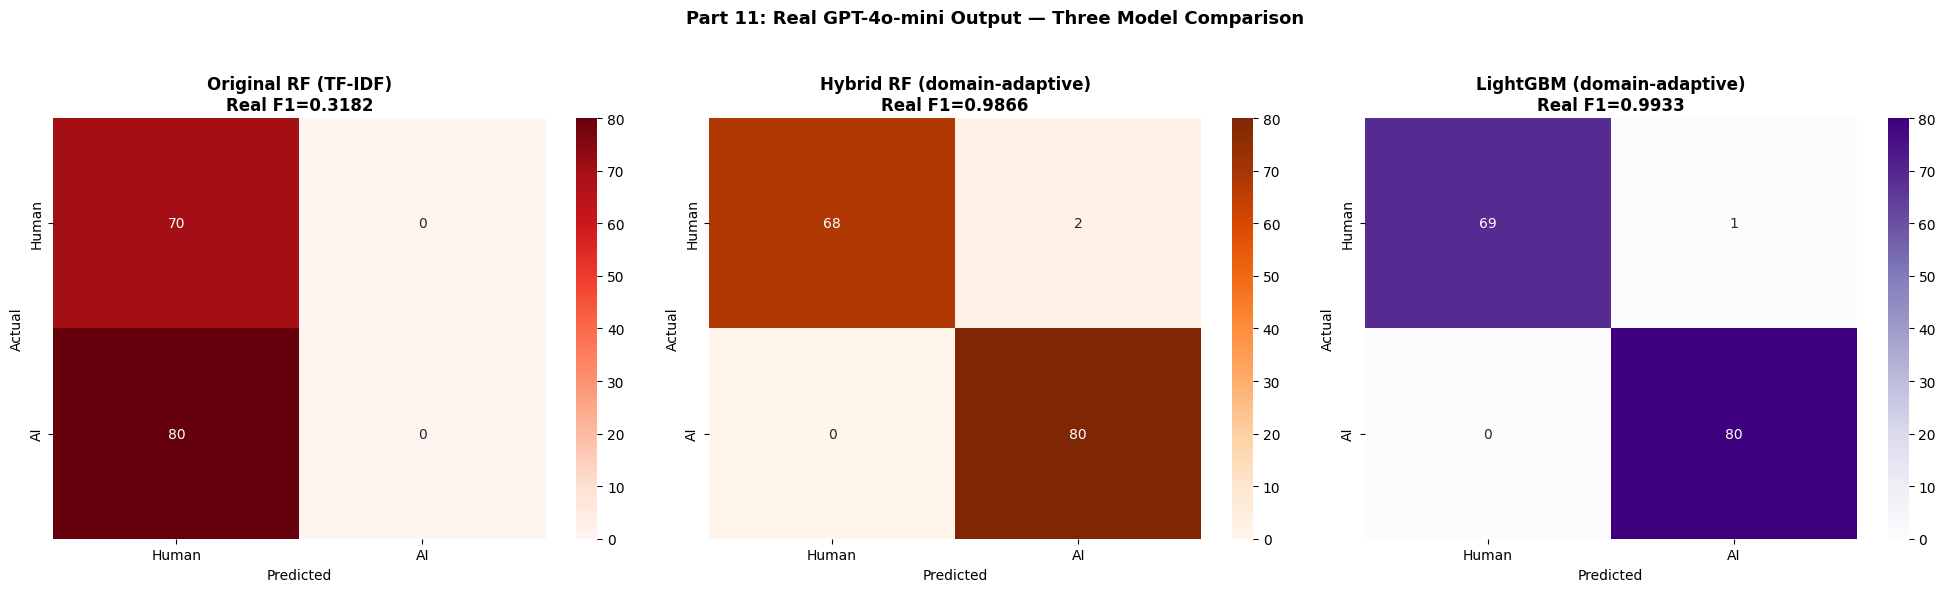

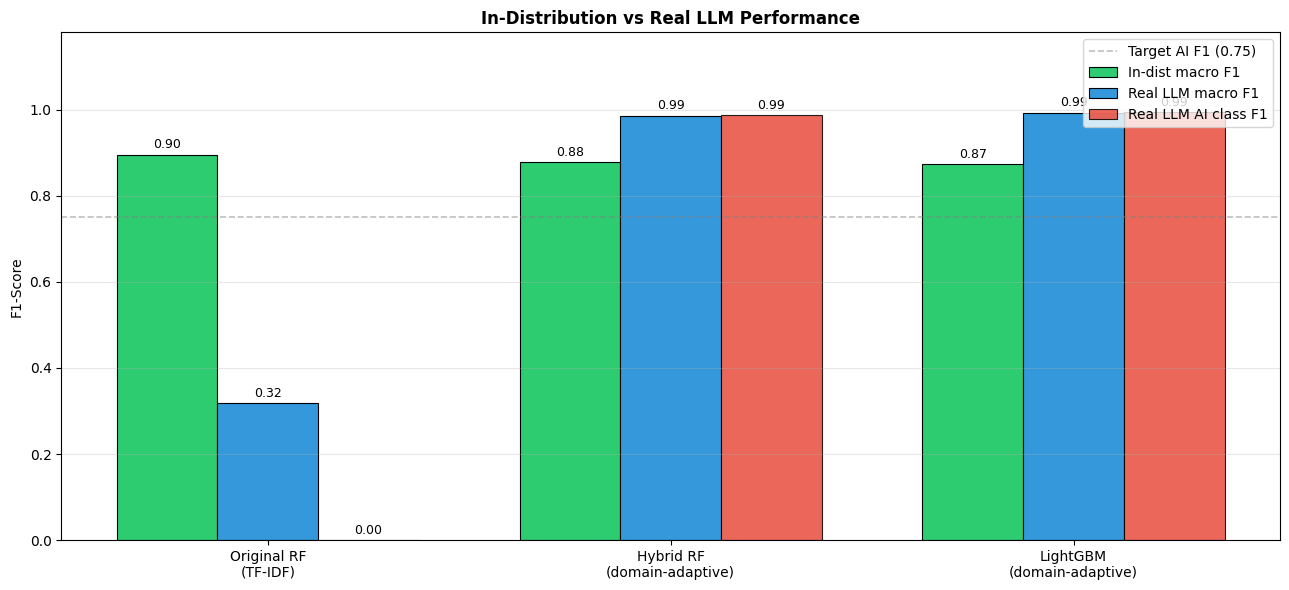

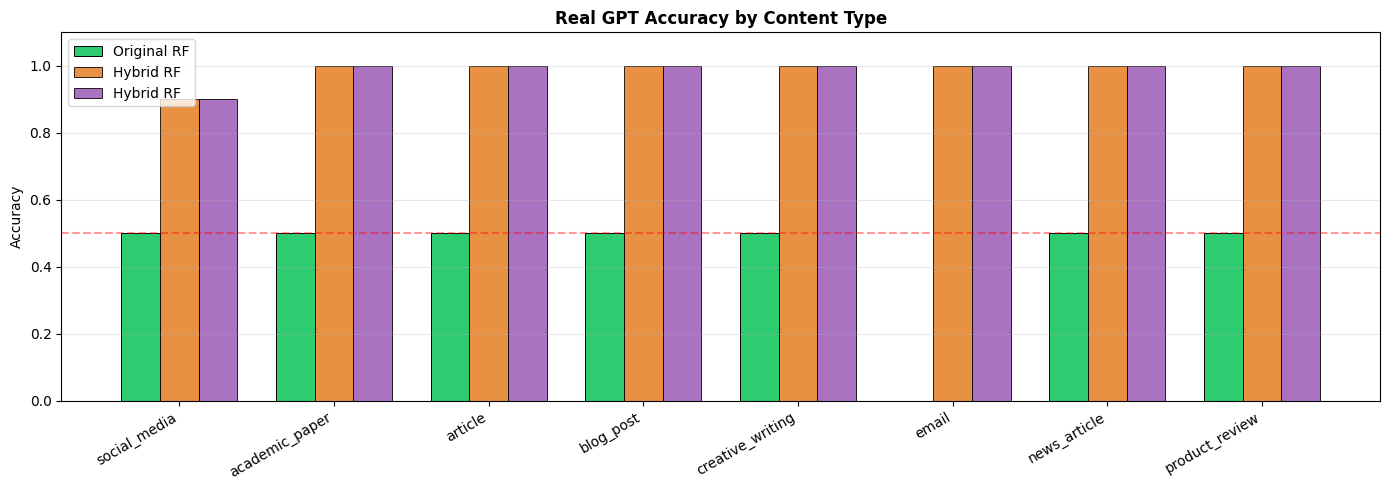

DEPLOYMENT DECISION
Hybrid RF meets target (AI F1=0.994 >= 0.75)
DEPLOY: Hybrid RF


In [ ]:
# PART 11c: VISUALISE GENERALISATION RESULTS
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
model_results = [
    (y_pred_orig,      f"Original RF (TF-IDF)\nReal F1={f1_orig_real:.4f}", "Reds"),
    (y_pred_rf_eval,   f"Hybrid RF (domain-adaptive)\nReal F1={f1_rf_real:.4f}", "Oranges"),
    (y_pred_lgbm_eval, f"LightGBM (domain-adaptive)\nReal F1={f1_lgbm_real:.4f}", "Purples"),
]

for ax, (preds, title, cmap) in zip(axes, model_results):
    cm = confusion_matrix(y_eval, preds, labels=[0, 1])
    sns.heatmap(cm, annot=True, fmt="d", cmap=cmap,
                xticklabels=["Human","AI"], yticklabels=["Human","AI"], ax=ax)
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.suptitle("Part 11: Real GPT-4o-mini Output — Three Model Comparison", fontsize=13, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

fig, ax = plt.subplots(figsize=(13, 6))
models = ["Original RF\n(TF-IDF)", "Hybrid RF\n(domain-adaptive)", "LightGBM\n(domain-adaptive)"]
in_dist_f1s = [ultimate_best["F1-Score"], f1_hybrid_val, f1_lgbm_val]
real_f1s = [f1_orig_real, f1_rf_real, f1_lgbm_real]
real_ai_f1s = [f1_orig_ai_real, f1_rf_ai_real, f1_lgbm_ai_real]

x = np.arange(len(models)); w = 0.25
b1 = ax.bar(x-w, in_dist_f1s, w, label="In-dist macro F1", color="#2ecc71", edgecolor="black", linewidth=0.8)
b2 = ax.bar(x,   real_f1s,    w, label="Real LLM macro F1", color="#3498db", edgecolor="black", linewidth=0.8)
b3 = ax.bar(x+w, real_ai_f1s, w, label="Real LLM AI class F1", color="#e74c3c", edgecolor="black", linewidth=0.8, alpha=0.85)

for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x()+bar.get_width()/2, h+0.008, f"{h:.2f}", ha="center", va="bottom", fontsize=9)

ax.axhline(0.75, linestyle="--", color="gray", alpha=0.5, linewidth=1.2, label="Target AI F1 (0.75)")
ax.set_xticks(x); ax.set_xticklabels(models)
ax.set_ylabel("F1-Score"); ax.set_ylim(0, 1.18)
ax.set_title("In-Distribution vs Real LLM Performance", fontweight="bold")
ax.legend(loc="upper right"); ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(14, 5))
ct_acc = df_real_eval.groupby("content_type")[["correct_orig","correct_hybrid","correct_ft"]].mean().sort_values("correct_ft")
x = np.arange(len(ct_acc)); w = 0.25
ax.bar(x-w, ct_acc["correct_orig"],   w, label="Original RF", color="#2ecc71", edgecolor="black", linewidth=0.7)
ax.bar(x,   ct_acc["correct_hybrid"], w, label="Hybrid RF",   color="#e67e22", edgecolor="black", linewidth=0.7, alpha=0.85)
ax.bar(x+w, ct_acc["correct_ft"],     w, label=deploy_name,   color="#9b59b6", edgecolor="black", linewidth=0.7, alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(ct_acc.index, rotation=30, ha="right")
ax.set_ylabel("Accuracy"); ax.legend()
ax.set_title("Real GPT Accuracy by Content Type", fontweight="bold")
ax.set_ylim(0, 1.1); ax.axhline(0.5, linestyle="--", alpha=0.4, color="red")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

print("="*70)
print("DEPLOYMENT DECISION")
print("="*70)
best_ai = max(f1_rf_ai_real, f1_lgbm_ai_real)
if best_ai >= 0.75:
    print(f"{deploy_name} meets target (AI F1={best_ai:.3f} >= 0.75)")
    print(f"DEPLOY: {deploy_name}")
elif best_ai >= 0.55:
    print(f"{deploy_name} partially meets target (AI F1={best_ai:.3f})")
    print(f"DEPLOY: {deploy_name} with documented limitations")
else:
    print(f"Both models below target. Best AI F1={best_ai:.3f}")
    print("Recommendation: increase GPT training samples (N_PER_TYPE=20) and re-run.")
print("="*70)


## Save Deployment Bundle — `models/avh_best_bundle.pkl`



In [ ]:
import os
import joblib
import torch
from datetime import datetime

save_dir = "models"
os.makedirs(save_dir, exist_ok=True)

torch.save(bert_model.state_dict(), os.path.join(save_dir, "avh_bert.pt"))

model_bundle = {
    "model": deploy_model,
    "model_name": deploy_name,
    "tfidf": tfidf_temp,
    "char": char_temp,
    "selector": selector_temp,
    "top_stylometric_indices": top_stylometric_indices,
    "expected_features": int(deploy_model.n_features_in_),
    "bert_model_name": "distilbert-base-uncased",
    "saved_at": datetime.now().isoformat(),
}

joblib.dump(model_bundle, os.path.join(save_dir, "avh_best_bundle.pkl"))

print(f"Saved best model bundle: {os.path.join(save_dir, 'avh_best_bundle.pkl')}")
print(f"Model: {deploy_name} | expected_features={model_bundle['expected_features']}")


Saved best model bundle: models/avh_best_bundle.pkl
Model: Hybrid RF | expected_features=788


## Part 12a — Error Analysis for Deploy Model on Real Eval Set

Runs a targeted error analysis on `df_real_eval` using the selected `deploy_model`:

1. **Classification report** — precision, recall, F1 per class
2. **Error breakdown** — counts of Correct, False Positive (Human → AI), False Negative (AI → Human)
3. **Confusion matrix** — heatmap for the deploy model on real eval
4. **Confidence distribution** — histogram of prediction confidence split by correct vs. error
5. **Error rate by content type** — bar chart showing which content categories the model struggles with most on real GPT output
6. **Top high-confidence errors** — the 10 most confidently wrong predictions displayed as a table

This is the real-world equivalent of the Phase 7 error analysis, but applied to the deploy model on genuinely AI-generated text rather than the synthetic SR test set.


  Embedded 32/150
Best model: Hybrid RF
Accuracy: 0.987
              precision    recall  f1-score   support

       Human       1.00      0.97      0.99        70
          AI       0.98      1.00      0.99        80

    accuracy                           0.99       150
   macro avg       0.99      0.99      0.99       150
weighted avg       0.99      0.99      0.99       150


Error breakdown:
error_type
Correct                         148
False Positive (Human -> AI)      2
Name: count, dtype: int64


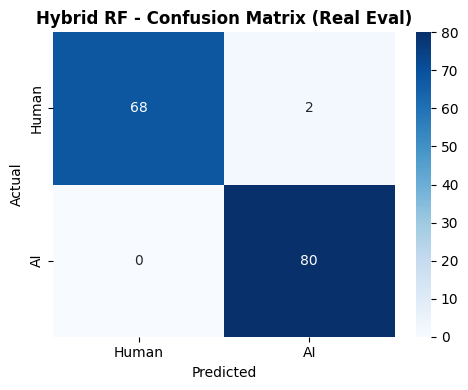

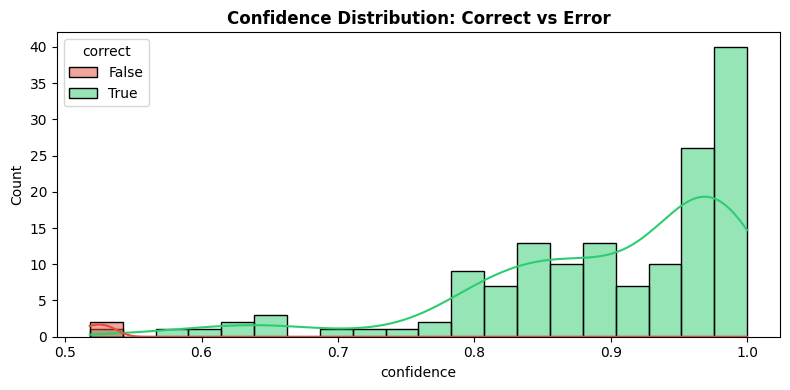

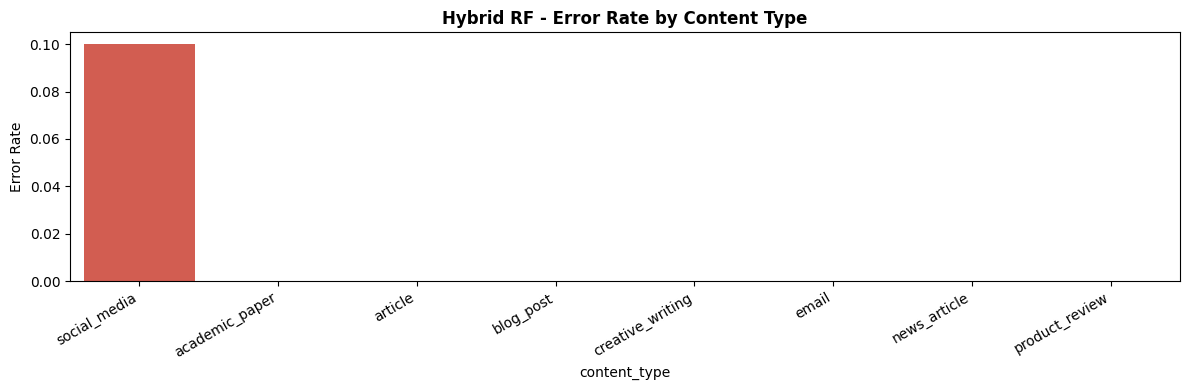


Top high-confidence errors:


,text_content,content_type,error_type,confidence,y_true,y_pred
122,Foreign campaign box direction material. Ago e...,social_media,False Positive (Human -> AI),0.531389,0,1
121,Physical thousand face issue people record com...,social_media,False Positive (Human -> AI),0.518000,0,1


In [ ]:
# PART 12a: ERROR ANALYSIS FOR BEST DEPLOY MODEL

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

if "deploy_model" not in globals():
    raise ValueError("deploy_model not found. Run Part 10b first.")
if "df_real_eval" not in globals() or len(df_real_eval) == 0:
    raise ValueError("df_real_eval not found/empty. Run the GPT generation cell first.")

X_classical_eval = build_classical_features(df_real_eval)
X_stylo_eval = X_classical_eval[:, top_stylometric_indices]
X_bert_eval = get_bert_embeddings(df_real_eval["text_content"].astype(str).tolist())
X_hybrid_eval = np.hstack([X_bert_eval, X_stylo_eval])

if hasattr(deploy_model, "n_features_in_") and X_hybrid_eval.shape[1] != deploy_model.n_features_in_:
    raise ValueError(f"Feature mismatch: X has {X_hybrid_eval.shape[1]}, model expects {deploy_model.n_features_in_}")

y_true = df_real_eval["label"].values
y_pred = deploy_model.predict(X_hybrid_eval)

if hasattr(deploy_model, "predict_proba"):
    probs = deploy_model.predict_proba(X_hybrid_eval)
    conf = probs.max(axis=1)
    p_ai = probs[:, 1]
else:
    dec = deploy_model.decision_function(X_hybrid_eval)
    dec = np.asarray(dec)
    conf = np.abs(dec) / (np.max(np.abs(dec)) if np.max(np.abs(dec)) != 0 else 1.0)
    p_ai = np.full_like(conf, np.nan, dtype=float)

ea = df_real_eval.copy()
ea["y_true"] = y_true
ea["y_pred"] = y_pred
ea["correct"] = (y_true == y_pred)
ea["confidence"] = conf
ea["p_ai"] = p_ai
ea["text_length"] = ea["text_content"].astype(str).str.len()

def err_type(r):
    if r["correct"]:
        return "Correct"
    if r["y_true"] == 0 and r["y_pred"] == 1:
        return "False Positive (Human -> AI)"
    return "False Negative (AI -> Human)"

ea["error_type"] = ea.apply(err_type, axis=1)

print(f"Best model: {deploy_name}")
print(f"Accuracy: {ea['correct'].mean():.3f}")
print(classification_report(y_true, y_pred, target_names=["Human", "AI"], zero_division=0))
print("\nError breakdown:")
print(ea["error_type"].value_counts())

cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Human", "AI"], yticklabels=["Human", "AI"])
plt.title(f"{deploy_name} - Confusion Matrix (Real Eval)", fontweight="bold")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
sns.histplot(data=ea, x="confidence", hue="correct", bins=20, kde=True,
             palette={True: "#2ecc71", False: "#e74c3c"})
plt.title("Confidence Distribution: Correct vs Error", fontweight="bold")
plt.tight_layout()
plt.show()

if "content_type" in ea.columns:
    ct = ea.groupby("content_type")["correct"].agg(["sum", "count"])
    ct["error_rate"] = 1 - (ct["sum"] / ct["count"])
    ct = ct.sort_values("error_rate", ascending=False)
    plt.figure(figsize=(12, 4))
    sns.barplot(x=ct.index, y=ct["error_rate"], color="#e74c3c")
    plt.xticks(rotation=30, ha="right")
    plt.ylabel("Error Rate")
    plt.title(f"{deploy_name} - Error Rate by Content Type", fontweight="bold")
    plt.tight_layout()
    plt.show()

print("\nTop high-confidence errors:")
show_cols = ["text_content", "content_type", "error_type", "confidence", "y_true", "y_pred"]
show_cols = [c for c in show_cols if c in ea.columns]
top_err = ea[~ea["correct"]].sort_values("confidence", ascending=False).head(10)[show_cols]
display(top_err)


## Part 12b — LIME Explanations for Deploy Model on Real Eval Set

Applies LIME to the deploy model (`deploy_model`) on real GPT-4o-mini samples to explain which words drove each prediction.

**Four passes:**
- **Pass 1** — Correct AI prediction (high confidence): shows which words pushed toward AI class
- **Pass 2** — Correct Human prediction (high confidence): shows which words pushed toward Human class
- **Pass 3** — False Negative #1 (AI predicted as Human, high confidence): reveals why the model was confidently wrong
- **Pass 4** — False Negative #2 (AI predicted as Human): second error case

Each pass produces a dual bar chart: LIME weights toward AI class (left) and LIME weights toward Human class (right).

Unlike Phase 9 LIME (which was applied to the TF-IDF RF), this LIME runs against the hybrid BERT deploy model, so weights may be more meaningful since the model isn't purely bigram-driven.



PASS 1 - Correct AI (High Confidence)
True: AI | Pred: AI | Conf: 1.000
Text: I recently purchased a pair of wireless noise-cancelling headphones, and they have significantly enhanced my listening experience. One of the standout features is the impressive noise cancellation technology, which effectively blocks out background sounds, making them perfect for...
  Embedded 32/500
  Embedded 352/500


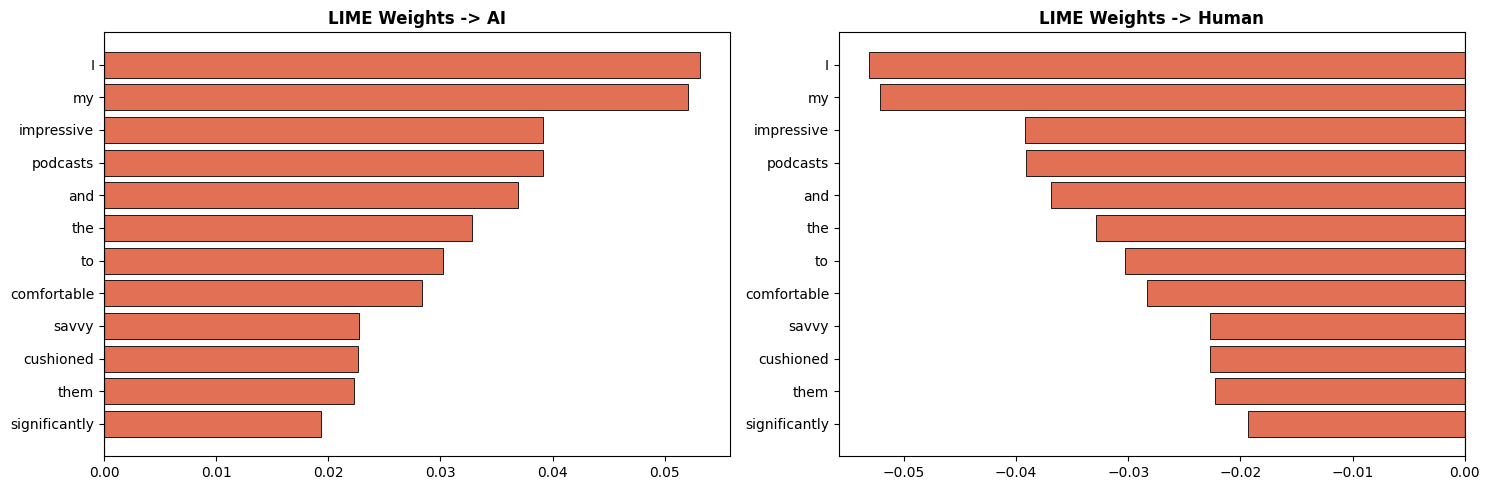


PASS 2 - Correct Human (High Confidence)
True: Human | Pred: Human | Conf: 0.921
Text: Place increase white thank raise among. Responsibility debate stop wait fire adult. Create region recent TV month trade stay agent.
Development production report Mr state. Instead talk other read believe these every.
Style happy great. Car line tonight create voice....
  Embedded 32/500
  Embedded 352/500


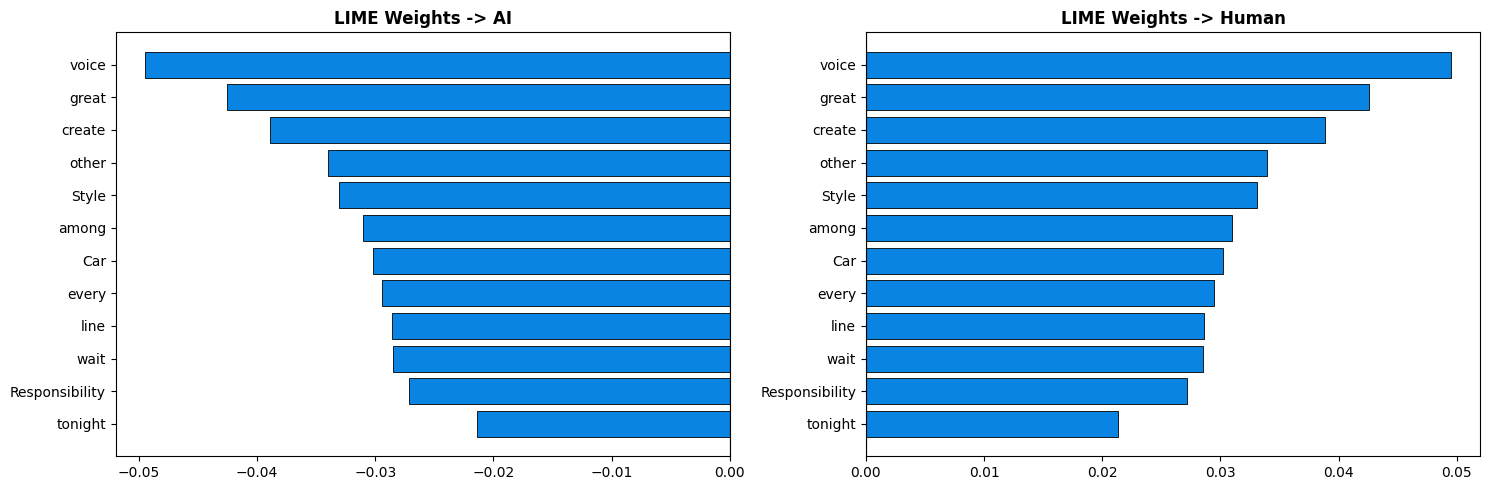

In [ ]:
# PART 12b: LIME EXPLANATIONS FOR BEST DEPLOY MODEL

import lime
import lime.lime_text
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def predict_proba_text_best(texts):
    texts = [str(t) for t in texts]
    df_tmp = pd.DataFrame({
        "text_content": texts,
        "content_type": ["article"] * len(texts)
    })
    X_class = build_classical_features(df_tmp)
    X_stylo = X_class[:, top_stylometric_indices]
    X_bert = get_bert_embeddings(texts)
    X_hybrid = np.hstack([X_bert, X_stylo])

    if hasattr(deploy_model, "n_features_in_") and X_hybrid.shape[1] != deploy_model.n_features_in_:
        raise ValueError(f"LIME feature mismatch: {X_hybrid.shape[1]} vs {deploy_model.n_features_in_}")

    if hasattr(deploy_model, "predict_proba"):
        return deploy_model.predict_proba(X_hybrid)

    d = deploy_model.decision_function(X_hybrid)
    d = np.asarray(d).reshape(-1)
    p1 = 1 / (1 + np.exp(-d))
    return np.vstack([1 - p1, p1]).T

explainer_lime = lime.lime_text.LimeTextExplainer(class_names=["Human", "AI"], random_state=42)
label_map = {0: "Human", 1: "AI"}

if "ea" not in globals():
    X_classical_eval = build_classical_features(df_real_eval)
    X_stylo_eval = X_classical_eval[:, top_stylometric_indices]
    X_bert_eval = get_bert_embeddings(df_real_eval["text_content"].astype(str).tolist())
    X_hybrid_eval = np.hstack([X_bert_eval, X_stylo_eval])
    y_pred = deploy_model.predict(X_hybrid_eval)
    probs = deploy_model.predict_proba(X_hybrid_eval) if hasattr(deploy_model, "predict_proba") else np.full((len(df_real_eval), 2), 0.5)
    ea = df_real_eval.copy()
    ea["y_true"] = df_real_eval["label"].values
    ea["y_pred"] = y_pred
    ea["correct"] = ea["y_true"] == ea["y_pred"]
    ea["confidence"] = probs.max(axis=1)

def run_lime_case(row, title, num_features=12):
    text = str(row["text_content"])
    true_label = int(row["y_true"])
    pred_label = int(row["y_pred"])
    conf = float(row["confidence"])

    print(f"\n{'='*70}")
    print(title)
    print(f"True: {label_map[true_label]} | Pred: {label_map[pred_label]} | Conf: {conf:.3f}")
    print(f"{'='*70}")
    print(f"Text: {text[:280]}...")

    exp = explainer_lime.explain_instance(
        text,
        predict_proba_text_best,
        num_features=num_features,
        num_samples=500,
        labels=[0, 1]
    )

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    for class_idx, ax, cname, pos, neg in [
        (1, axes[0], "AI", "#e17055", "#0984e3"),
        (0, axes[1], "Human", "#0984e3", "#e17055"),
    ]:
        ww = exp.as_list(label=class_idx)
        words = [w for w, _ in ww]
        vals = [v for _, v in ww]
        colors = [pos if v > 0 else neg for v in vals]
        ax.barh(words[::-1], vals[::-1], color=colors[::-1], edgecolor="black", linewidth=0.6)
        ax.axvline(0, color="black", linewidth=0.8)
        ax.set_title(f"LIME Weights -> {cname}", fontweight="bold")
    plt.tight_layout()
    plt.show()
    return exp

cases = []

c1 = ea[(ea["correct"]) & (ea["y_true"] == 1)].sort_values("confidence", ascending=False).head(1)
if len(c1): cases.append(("PASS 1 - Correct AI (High Confidence)", c1.iloc[0]))

c2 = ea[(ea["correct"]) & (ea["y_true"] == 0)].sort_values("confidence", ascending=False).head(1)
if len(c2): cases.append(("PASS 2 - Correct Human (High Confidence)", c2.iloc[0]))

fn = ea[(~ea["correct"]) & (ea["y_true"] == 1)].sort_values("confidence", ascending=False).head(2)
for i in range(len(fn)):
    cases.append((f"PASS {3+i} - False Negative #{i+1} (AI -> Human)", fn.iloc[i]))

if len(cases) == 0:
    print("No eligible rows found for LIME passes.")
else:
    lime_explanations = []
    for title, row in cases:
        exp = run_lime_case(row, title)
        lime_explanations.append((title, exp))


## Part 13 — Low-FP Upgrade: Calibrated LightGBM v2

Addresses the deployment risk identified in Phase 7 and Part 12a: the model is directionally biased toward False Negatives but has a non-trivial False Positive rate that would flag human text as AI-generated.

**Three-step approach:**
1. **Leak-safe split** — splits the full training pool (SR synthetic + real GPT) *before* augmentation, then applies human-style augmentation (typo injection, casual-style conversion, text shortening) to training human samples only
2. **Calibrated LightGBM** — wraps a new LightGBM (n_estimators=600, lr=0.04) in `CalibratedClassifierCV(method='sigmoid', cv=3)` to produce reliable probability estimates
3. **Threshold tuning** — grid search over thresholds 0.50–0.95 to find the highest macro F1 subject to a human False Positive rate ≤ 5%.

**Saves:** `models/avh_best_bundle_v2.pkl` — includes the calibrated model, all pipeline objects, the recommended threshold, and the FP target for the Streamlit app to use at inference time.


In [ ]:
# PART 13: LOW-FP UPGRADE (Leak-safe split + real-human threshold tuning)

import os
import re
import random
import numpy as np
import pandas as pd
import joblib
import lightgbm as lgb

from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from sklearn.calibration import CalibratedClassifierCV

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

SLANG_MAP = {
    "you": "u", "your": "ur", "are": "r", "to": "2", "for": "4",
    "because": "cuz", "please": "pls", "people": "ppl","really":"rlly", "i do not know": "idk", "laughing":"lmao","me":"meee","the": "theee", "great": "gr8"
}

def inject_typos(text, prob=0.02):
    chars = list(text)
    out = []
    for ch in chars:
        if ch.isalpha() and random.random() < prob:
            r = random.random()
            if r < 0.33:
                continue
            elif r < 0.66:
                out.append(ch)
                out.append(ch)
            else:
                out.append(ch.swapcase())
        else:
            out.append(ch)
    return "".join(out)

def to_casual_style(text):
    toks = text.split()
    out = []
    for t in toks:
        key = re.sub(r"[^a-zA-Z]", "", t).lower()
        out.append(SLANG_MAP.get(key, t))
    s = " ".join(out)
    s = re.sub(r"\bI am\b", "I'm", s)
    s = re.sub(r"\bdo not\b", "don't", s, flags=re.I)
    s = re.sub(r"\bcannot\b", "can't", s, flags=re.I)
    return s

def shorten_text(text, keep_ratio=0.5):
    words = text.split()
    if len(words) < 20:
        return text
    k = max(8, int(len(words) * keep_ratio))
    return " ".join(words[:k])

def diversify_human_text(text):
    return [
        inject_typos(text, prob=0.02),
        to_casual_style(text),
        shorten_text(text, keep_ratio=0.5),
    ]

if "all_texts" in globals() and "all_labels" in globals() and "all_ct" in globals():
    base_df = pd.DataFrame({
        "text_content": [str(t) for t in all_texts],
        "label": list(map(int, all_labels)),
        "content_type": [str(c) for c in all_ct],
    })
else:
    base_df = augmented_df_sr[["text_content", "label", "content_type"]].copy()
    if "df_real_eval" in globals() and len(df_real_eval):
        tmp = df_real_eval.copy()
        for col in ["text_content", "label", "content_type"]:
            if col not in tmp.columns:
                tmp[col] = "article" if col == "content_type" else 0
        base_df = pd.concat([base_df, tmp[["text_content", "label", "content_type"]]], ignore_index=True)

# optional extra real human corpus
extra_human_path = "real_human_extra.csv"
if os.path.exists(extra_human_path):
    extra_human = pd.read_csv(extra_human_path)
    if "text_content" in extra_human.columns:
        extra_human["label"] = 0
        if "content_type" not in extra_human.columns:
            extra_human["content_type"] = "article"
        base_df = pd.concat(
            [base_df, extra_human[["text_content", "label", "content_type"]]],
            ignore_index=True
        )
        print(f"Loaded external human corpus: {len(extra_human):,} rows")

# de-dup first
base_df["text_content"] = base_df["text_content"].astype(str).str.strip()
base_df = base_df.drop_duplicates(subset=["text_content", "label"]).reset_index(drop=True)
print(f"Base pool (dedup): {len(base_df):,}")

train_base, val_base = train_test_split(
    base_df, test_size=0.2, random_state=RANDOM_STATE, stratify=base_df["label"]
)

# Augment only train human samples
human_train = train_base[train_base["label"] == 0].copy()
aug_rows = []
for _, row in human_train.iterrows():
    txt = str(row["text_content"])
    for v in diversify_human_text(txt):
        aug_rows.append({
            "text_content": v,
            "label": 0,
            "content_type": row.get("content_type", "article")
        })

human_aug_df = pd.DataFrame(aug_rows)
train_df_v2 = pd.concat([train_base, human_aug_df], ignore_index=True)
train_df_v2 = train_df_v2.drop_duplicates(subset=["text_content", "label"]).reset_index(drop=True)
val_df_v2 = val_base.copy()

print(f"Train base: {len(train_base):,}")
print(f"Human aug added: {len(human_aug_df):,}")
print(f"Train final: {len(train_df_v2):,}")
print(f"Val final: {len(val_df_v2):,}")

def build_classical_from_df(df_in):
    df_e = df_in.copy()
    if "content_type" not in df_e.columns:
        df_e["content_type"] = "article"

    intrinsic_cols = [
        "word_count","character_count","sentence_count","lexical_diversity",
        "avg_sentence_length","avg_word_length","punctuation_ratio",
        "flesch_reading_ease","gunning_fog_index","grammar_errors",
        "passive_voice_ratio","predictability_score","burstiness","sentiment_score"
    ]

    intr_df = pd.DataFrame(list(df_e["text_content"].astype(str).apply(calculate_intrinsic_features)))
    for c in intrinsic_cols:
        df_e[c] = intr_df.get(c, 0)
        df_e[c] = df_e[c].fillna(0)

    X_num = df_e[intrinsic_cols].values
    adv_df = pd.DataFrame(list(df_e["text_content"].astype(str).apply(extract_advanced_features)))

    if "content_type" in augmented_df_sr.columns:
        ct_cols = pd.get_dummies(
            augmented_df_sr["content_type"], prefix="content", drop_first=True
        ).columns.tolist()
    else:
        ct_cols = []

    ct_dum = pd.get_dummies(df_e["content_type"], prefix="content", drop_first=False)
    for c in ct_cols:
        if c not in ct_dum.columns:
            ct_dum[c] = 0
    ct_dum = ct_dum[ct_cols] if ct_cols else pd.DataFrame(index=df_e.index)

    X_tf = tfidf_temp.transform(df_e["text_content"].astype(str)).toarray()
    X_ch = char_temp.transform(df_e["text_content"].astype(str)).toarray()

    X_all = np.hstack([X_num, adv_df.values, ct_dum.values, X_tf, X_ch])
    return selector_temp.transform(np.abs(X_all))

# train/val matrices
X_bert_tr = get_bert_embeddings(train_df_v2["text_content"].astype(str).tolist())
X_cls_tr = build_classical_from_df(train_df_v2)

X_bert_va = get_bert_embeddings(val_df_v2["text_content"].astype(str).tolist())
X_cls_va = build_classical_from_df(val_df_v2)

if "top_stylometric_indices" in globals() and len(top_stylometric_indices):
    sty_idx = np.array(top_stylometric_indices)
else:
    sty_idx = np.arange(min(20, X_cls_tr.shape[1]))

X_tr = np.hstack([X_bert_tr, X_cls_tr[:, sty_idx]])
X_va = np.hstack([X_bert_va, X_cls_va[:, sty_idx]])

y_tr = train_df_v2["label"].astype(int).values
y_va = val_df_v2["label"].astype(int).values

print("Hybrid train shape:", X_tr.shape)
print("Hybrid val shape:", X_va.shape)

base_lgbm_v2 = lgb.LGBMClassifier(
    n_estimators=600,
    learning_rate=0.04,
    num_leaves=63,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_alpha=0.15,
    reg_lambda=0.15,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=-1
)

cal_lgbm_v2 = CalibratedClassifierCV(
    estimator=base_lgbm_v2,
    method="sigmoid",
    cv=3
)
cal_lgbm_v2.fit(X_tr, y_tr)

p_ai_va = cal_lgbm_v2.predict_proba(X_va)[:, 1]

FP_TARGET = 0.05
thr_grid = np.arange(0.50, 0.96, 0.01)

best_thr = 0.80
best_f1 = -1.0

for thr in thr_grid:
    pred = (p_ai_va >= thr).astype(int)
    human_mask = (y_va == 0)
    fp_rate = pred[human_mask].mean() if human_mask.any() else 0.0
    if fp_rate <= FP_TARGET:
        f1m = f1_score(y_va, pred, average="macro", zero_division=0)
        if f1m > best_f1:
            best_f1 = f1m
            best_thr = float(np.round(thr, 2))

holdout_path = "real_human_holdout.csv"
if os.path.exists(holdout_path):
    hh = pd.read_csv(holdout_path)
    if "text_content" in hh.columns and len(hh) > 0:
        hh = hh.copy()
        hh["label"] = 0
        hh["content_type"] = hh.get("content_type", "article")
        Xh = np.hstack([
            get_bert_embeddings(hh["text_content"].astype(str).tolist()),
            build_classical_from_df(hh)[:, sty_idx]
        ])
        p_ai_h = cal_lgbm_v2.predict_proba(Xh)[:, 1]
        target_fp_holdout = 0.02
        valid = [t for t in thr_grid if (p_ai_h >= t).mean() <= target_fp_holdout]
        if valid:
            best_thr = float(np.round(max(valid), 2))
            print(f"Threshold updated by real_human_holdout.csv: {best_thr:.2f} (FP<={target_fp_holdout:.2%})")

pred_050 = (p_ai_va >= 0.50).astype(int)
pred_best = (p_ai_va >= best_thr).astype(int)

print(f"Validation macro F1 @0.50: {f1_score(y_va, pred_050, average='macro', zero_division=0):.4f}")
print(f"Validation macro F1 @{best_thr:.2f}: {f1_score(y_va, pred_best, average='macro', zero_division=0):.4f}")
print(f"Selected threshold: {best_thr:.2f} (FP target <= {FP_TARGET:.2%})")
print(classification_report(y_va, pred_best, target_names=["Human", "AI"], zero_division=0))
print("Confusion matrix @best threshold:")
print(confusion_matrix(y_va, pred_best))


save_dir = "models"
os.makedirs(save_dir, exist_ok=True)

bundle_v2 = {
    "model": cal_lgbm_v2,
    "model_name": "Calibrated LightGBM (v2)",
    "tfidf": tfidf_temp,
    "char": char_temp,
    "selector": selector_temp,
    "top_stylometric_indices": np.array(sty_idx),
    "expected_features": int(X_tr.shape[1]),
    "bert_model_name": "distilbert-base-uncased",
    "recommended_threshold": float(best_thr),
    "fp_target": float(FP_TARGET),
}

out_path = os.path.join(save_dir, "avh_best_bundle_v2.pkl")
joblib.dump(bundle_v2, out_path)
print(f"Saved: {out_path}")
print("Use this bundle in Streamlit.")


Base pool (dedup): 2,599
Train base: 2,079
Human aug added: 3,036
Train final: 4,872
Val final: 520
  Embedded 32/4872
  Embedded 352/4872
  Embedded 672/4872
  Embedded 992/4872
  Embedded 1312/4872
  Embedded 1632/4872
  Embedded 1952/4872
  Embedded 2272/4872
  Embedded 2592/4872
  Embedded 2912/4872
  Embedded 3232/4872
  Embedded 3552/4872
  Embedded 3872/4872
  Embedded 4192/4872
  Embedded 4512/4872
  Embedded 4832/4872
  Embedded 32/520
  Embedded 352/520
Hybrid train shape: (4872, 788)
Hybrid val shape: (520, 788)
Validation macro F1 @0.50: 0.8709
Validation macro F1 @0.60: 0.8608
Selected threshold: 0.60 (FP target <= 5.00%)
              precision    recall  f1-score   support

       Human       0.80      0.96      0.87       253
          AI       0.95      0.77      0.85       267

    accuracy                           0.86       520
   macro avg       0.88      0.86      0.86       520
weighted avg       0.88      0.86      0.86       520

Confusion matrix @best thresho